In [1]:
%reload_ext autoreload
%autoreload 2

from MBN_Res_Constrn import MBN_RC
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Time series

Store all iteration data in a .csv file

In [2]:
#put network you are using eg, full, node removed
name='RE'

#put itr as number of iterations you want
itr=200
#to get and store iterations data
c=0

#to store iteration data
df_itr=pd.DataFrame()   

#to store local order data
df_loc_data = pd.DataFrame()

#Lists to store transition time and time spent in sync state
trans_time=[]
state_time=[]


while c<itr:
    print("Current iteration is",c)
    mbn = MBN_RC(nepochs=40000, 
                 dt=0.05, 
                 lambda_o=2.86, 
                 alpha=0.01,
                 beta=0.002,
                 plot_bifurcation=False)
    
    mbn.run_model()

    #df to store 1 iteration data
    df=pd.DataFrame(mbn.GLOBAL_ORDER_VERBOSE)
    #concatenating each iteration as a column
    df_itr=pd.concat([df_itr,df], axis=1)

    #changing headers to number of iterations
    df_itr.columns=range(0,df_itr.shape[1])
    #storing dataframe in csv file
    df_itr.to_csv("data.csv")

    #smoothing the dataframe
    df_smooth=df.rolling(window=800, center=True).mean()

    #defining time and timesteps for data
    time_steps = list(range(0,df_itr.shape[0]))   
    time=np.multiply(time_steps,mbn.dt)

    #dropping the NaN values
    df_na = df_smooth.dropna()
    

    #defining time and time steps for df_na data
    #can drop these 2 lines
    time_steps_na = list(range(0,df_na.shape[0])) 
    time_na=np.multiply(time_steps_na,mbn.dt)

    
    data = np.array(df_na)
    #Looping one cycle of finding transition and time spent in sync state
    while True:
        
        index_arr=np.where(data >= 0.4)[0]

        #Finding if iteration has a transition
        if index_arr.size > 0:
            upper_crossing = index_arr[0]
           #finding transition time thresholds     
            l1 = np.where(data >= 0.1)[0]
            l2=np.where(data <= 0.101)[0]
            low_intersection = np.intersect1d(l1, l2)
            #making sure lower thresholds are for 1st transition
            low_upd =low_intersection[low_intersection<upper_crossing]

            lower_crossing=low_upd[-1]
        
            t=(upper_crossing-lower_crossing)*mbn.dt
            trans_time.append(t)
            #trans_df=pd.concat([trans_df, df_na[i]], axis=1)
            #trans_df stores the iterations which have transitions

            #Extracting local order data for above iteration
            df_dum = pd.DataFrame()
            #defining local order data timestep thresholds
        
            #checking where it crossed 0.3
            m_loc=np.where(data >= 0.3)[0][0]
        

        
            lt_loc = m_loc - 3000
            ut_loc = m_loc + 2000

            #extracting data from df_loc
            header_list=list(range(lt_loc,ut_loc))
            #filtering those columns which lie in between 0 to mbn.nepochs
            header_list_f = [x for x in header_list if 0 <= x < mbn.nepochs]
            df_dum = mbn.df_loc[header_list_f]
            #changing column numbers so that they be concated 1 below other
            df_dum.columns = range(0,df_dum.shape[1])
            

            #creating multi-index dataframe
            index=[[c]*426,list(range(0,426))]
            df_dum=df_dum.set_index(index)
            df_loc_data = pd.concat([df_loc_data,df_dum])
            
            

        
            #checking for another transition
            fwd_data=np.array(data[upper_crossing:])
        

            #upper_crs=np.where(fwd_data >= 0.45)[0][-1]
            check=np.where(fwd_data <= 0.2)[0]

            if check.size > 0:
                ind=np.where(fwd_data <= 0.1)[0]
                if ind.size > 0:

                    lower_crs = ind[0]
                    lower_crs_up = lower_crs+upper_crossing
                    st_time=(lower_crs_up-lower_crossing)*mbn.dt
                    state_time.append(st_time)
                    #creating data for other cycle of transition and state time
                    data= np.array(data[lower_crs_up:])
                #trans_2df=pd.concat([trans_2df, df_na[i]], axis=1)
                else:
                    
                    break
                    

            else:
                #continue
                
                break
                

        else:
                #data_no_trans=pd.concat([data_no_trans, df_na[i]], axis=1)
            
            break
    
    #increasing count by 1
    c+=1
 

    
#define network for which you are calculatingab

df_tt = pd.DataFrame(trans_time,columns=[name])
df_st=  pd.DataFrame(state_time,columns=[name])


print(np.array(trans_time))
print(np.array(state_time))
print(f'The number of iterations with transition is {len(trans_time)}')    
print(f'The number of iterations with more than 1 transition is {len(state_time)}') 


df_tt.to_csv('tt_200.csv')
df_st.to_csv('st_200.csv')
df_loc_data=df_loc_data.astype(np.float32)
df_loc_data.to_pickle('l200.bz2',compression='bz2')

Current iteration is 0
/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/../Model/tES/tES_Adaptive.py:141: RuntimeWarning: divide by zero encountered in divide
  K_ = 1 / self.K


0.42310864955417976
Current iteration is 1
/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/../Model/tES/tES_Adaptive.py:141: RuntimeWarning: divide by zero encountered in divide
  K_ = 1 / self.K


0.05301286168587399
Current iteration is 2
/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


...

0.31097027291240703
Current iteration is 198
/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/../Model/tES/tES_Adaptive.py:141: RuntimeWarning: divide by zero encountered in divide
  K_ = 1 / self.K


0.04255480647294907
Current iteration is 199
/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized


/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/../Model/tES/tES_Adaptive.py:141: RuntimeWarning: divide by zero encountered in divide
  K_ = 1 / self.K


0.5334358599392268
[ 36.25  36.25  88.35  68.05  57.25  68.55  33.25  58.3   33.05  27.8
  38.6   29.   358.65  26.05 146.1   34.95  32.2   97.8   58.25  45.8
  33.55  39.35  68.85  37.55  33.05  61.45  53.85  28.5   27.25  40.3
  27.45  32.    30.3   38.15  38.1  161.65  93.9  107.75  31.65  66.5
  35.55  37.7   39.5   36.   124.05  30.95  32.1   30.9   45.    36.7
  37.35  34.2   30.15  41.35  93.5   51.95 105.5   27.5   37.65  41.45
  78.7   39.9   33.2   30.85  31.45  34.2   76.7   90.4  100.8   31.8
  46.4   32.65  32.9   31.25  32.9   30.05  39.2   73.65 114.4   31.8
  83.45  64.4   33.85 100.9   52.95 291.4   30.35  45.15  56.05  38.1
  31.65  27.2   70.05  26.15  32.4  131.3   50.35  47.25  30.75  57.
  37.8   31.7  124.35  39.95  29.8   35.4   39.8   42.8   44.    39.9
  30.5   35.45  32.4   40.2   27.6 ]
[633.5  163.9  130.8  267.2   93.7  189.85 193.8  158.2  128.45 114.55
 158.4   88.35 388.85 119.95 223.7   69.65 397.8  356.25 128.6  169.4
 132.6  115.2  839.9  145.8  400.

In [3]:
df_loc_data.head()

0         1         2         3         4         5         6     \
5 0  0.287662  0.289669  0.291779  0.293987  0.296285  0.298666  0.301122   
  1  0.155952  0.158937  0.161974  0.165061  0.168190  0.171358  0.174559   
  2  0.187938  0.189596  0.191329  0.193132  0.195001  0.196930  0.198916   
  3  0.122795  0.124877  0.126913  0.128902  0.130844  0.132738  0.134584   
  4  0.170761  0.169844  0.169046  0.168367  0.167809  0.167370  0.167050   

         7         8         9     ...      4990      4991      4992  \
5 0  0.303644  0.306221  0.308845  ...  0.695572  0.694946  0.694398   
  1  0.177786  0.181033  0.184294  ...  0.466242  0.466677  0.467185   
  2  0.200953  0.203037  0.205163  ...  0.666067  0.666363  0.666635   
  3  0.136382  0.138134  0.139840  ...  0.506528  0.510867  0.515311   
  4  0.166845  0.166752  0.166768  ...  0.577200  0.578237  0.579335   

         4993      4994      4995      4996      4997      4998      4999  
5 0  0.693922  0.693511  0.693157  0.692854  0.692594  0.692371  0.692178  
  1  0.467763  0.468405  0.469107  0.469866  0.470677  0.471537  0.472441  
  2  0.666881  0.667098  0.667286  0.667444  0.667572  0.667672  0.667744  
  3  0.519844  0.524451  0.529114  0.533818  0.538545  0.543278  0.548001  
  4  0.580494  0.581713  0.582994  0.584335  0.585738  0.587202  0.588727  

[5 rows x 5000 columns]

In [3]:
df_loc_data.shape

(4686, 5000)

In [4]:
df_itr.shape

(40000, 20)

In [5]:
df_tt.head()

,Full Network
0,26.40
1,268.70
2,72.35
3,31.30
4,26.30


In [7]:
df_st.head()

,Full Network
0,404.25
1,309.75
2,297.70
3,740.30
4,725.90


In [8]:
df_tt.to_csv('tt_200.csv')

In [9]:
df_st.to_csv('st_200.csv')

In [7]:
(mbn.df_loc).shape

(426, 40700)

In [5]:
df_loc_data

7351      7352      7353      7354      7355      7356      7357   \
2  0    0.195702  0.194941  0.194416  0.194116  0.194031  0.194148  0.194450   
   1    0.132879  0.135980  0.138909  0.141665  0.144245  0.146649  0.148874   
   2    0.122148  0.124747  0.127165  0.129395  0.131433  0.133274  0.134914   
   3    0.225605  0.231528  0.237141  0.242433  0.247396  0.252023  0.256310   
   4    0.090574  0.096026  0.101342  0.106514  0.111533  0.116393  0.121088   
...          ...       ...       ...       ...       ...       ...       ...   
29 421       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   422       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   423       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   424       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
   425       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

           7358      7359      7360   ...     19361     19362     19363  \
2  0    0.194922  0.195544  0.196298  ...       NaN       NaN       NaN   
   1    0.150920  0.152785  0.154467  ...       NaN       NaN       NaN   
   2    0.136349  0.137578  0.138599  ...       NaN       NaN       NaN   
   3    0.260253  0.263849  0.267094  ...       NaN       NaN       NaN   
   4    0.125614  0.129966  0.134140  ...       NaN       NaN       NaN   
...          ...       ...       ...  ...       ...       ...       ...   
29 421       NaN       NaN       NaN  ...  0.467702  0.471302  0.474286   
   422       NaN       NaN       NaN  ...  0.203665  0.205443  0.207402   
   423       NaN       NaN       NaN  ...  0.137519  0.140893  0.144189   
   424       NaN       NaN       NaN  ...  0.270509  0.274697  0.278534   
   425       NaN       NaN       NaN  ...  0.331889  0.334901  0.337782   

           19364     19365     19366     19367     19368     19369     19370  
2  0         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
   1         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
   2         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
   3         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
   4         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
...          ...       ...       ...       ...       ...       ...       ...  
29 421  0.476655  0.478407  0.479545  0.480071  0.479989  0.479305  0.478025  
   422  0.209540  0.211851  0.214329  0.216967  0.219755  0.222683  0.225741  
   423  0.147404  0.150537  0.153584  0.156546  0.159419  0.162203  0.164896  
   424  0.282011  0.285125  0.287868  0.290238  0.292231  0.293846  0.295081  
   425  0.340529  0.343141  0.345615  0.347950  0.350143  0.352194  0.354099  

[6816 rows x 13052 columns]

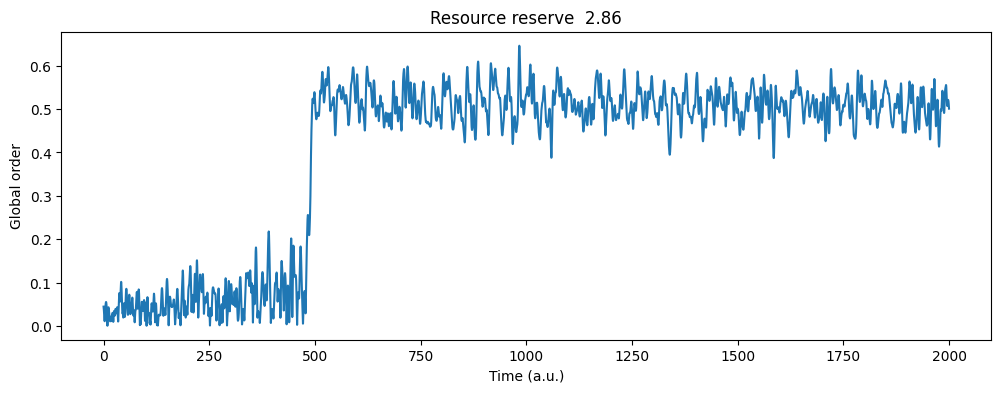

In [6]:
f = plt.figure(figsize=(12, 4))
plt.title("Resource reserve  " + str(mbn.LAMBDA_O)) 
plt.plot(np.linspace(0, mbn.NEPOCHS-1, mbn.NEPOCHS)*mbn.DT, mbn.GLOBAL_ORDER_VERBOSE)
plt.ylabel("Global order")
plt.xlabel("Time (a.u.)")
plt.show()

### Bifurcation diagram

In [ ]:
mbn = MBN_RC(nepochs=2400000, 
             dt=0.05, 
             lambda_o=2.87, 
             plot_bifurcation=True, 
             epochs_per_lambda_o=40000, 
             step_size_lambda_o=0.01)
mbn.run_model()

/home/jupyter-nimish/srg-tes-epilepsy-models/analysis/Mouse brain network/MouseBrainLib/mb_communities.npz already exists
DataUtils initialized
Average shortest path length:  2.1057608395470866
Avg clustering coefficient:  0.37852781810835767

LAMBDA_O=2.88, Global Order (R)=0.044016437983469776

LAMBDA_O=2.88, Global Order(R)=0.044016437983469776
LAMBDA_O=2.88, Global Order(R)=0.07110784954454008
LAMBDA_O=2.88, Global Order(R)=0.03132959709201885
LAMBDA_O=2.88, Global Order(R)=0.21249753041620725


**Loading from saved file instead**

In [ ]:
loaded_data = np.load("../../../../datastore/explosive_sync/Mouse brain network/mb_data_adaptive_a_0.01_b_0.002.npz")

GLOBAL_ORDER_VERBOSE_RC = loaded_data['arr1']
LAMBDA_O_RC_ = loaded_data['arr2']
# LAMBDA_RC_ = loaded_data['arr3']

print("done")

In [20]:
noise = np.random.normal(loc=0.0, scale=0.006, size=LAMBDA_O_RC_.shape)
LAMBDA_O_RC_noise = LAMBDA_O_RC_ + noise

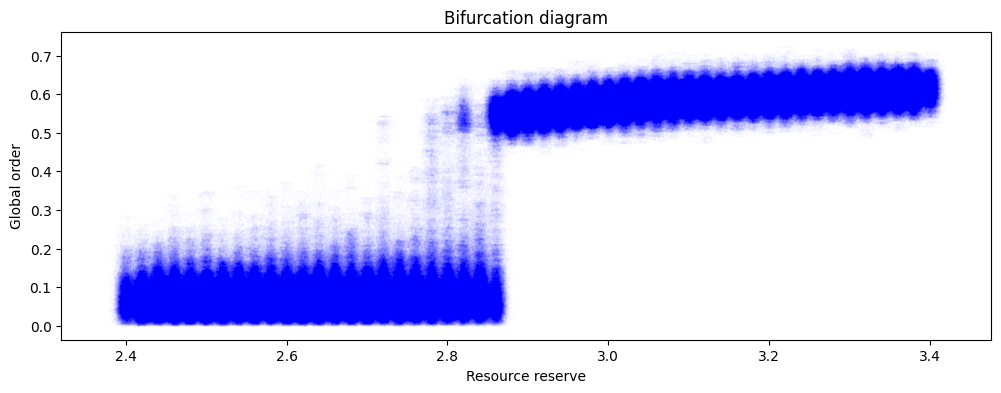

In [22]:
f = plt.figure(figsize=(12, 4))
plt.title("Bifurcation diagram") 

plt.scatter(LAMBDA_O_RC_noise, GLOBAL_ORDER_VERBOSE_RC, 
            s=0.05, alpha=0.03, color='blue')

plt.ylabel("Global order")
plt.xlabel("Resource reserve")
plt.show()